# PHLOP QA Data Analysis

Memory-efficient analysis of question distributions across splits.
Processes one shard at a time to avoid filling disk with extracted zips.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import os
import shutil
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

REPO_ID = "zimmari-ai/phlop"
HF_TOKEN = os.environ.get("HF_TOKEN") or True  # True = use cached huggingface_hub.login()

## 1. Load parquet metadata (lightweight)

Only downloads the small parquet index files (paths, IDs, shard_file). No video data.

In [ ]:
splits = load_dataset(
    REPO_ID,
    data_files={
        "train": "train_shard_*.parquet",
        "val": "val_shard_*.parquet",
        "test": "test_shard_*.parquet",
    },
    token=HF_TOKEN,
)

for name in splits:
    print(f"{name}: {len(splits[name])} rows, columns: {list(splits[name].features.keys())}")

## 2. Batch analysis function

Groups rows by `shard_file`, processes one shard at a time,
then deletes the extracted directory to free disk.

In [4]:
def classify_answer_format(qa: dict) -> str:
    """Classify a QA entry's answer into a format category."""
    ans = qa.get("answer", "")
    if isinstance(ans, bool) or str(ans).lower() in ("yes", "no", "true", "false"):
        return "Boolean / Yes-No"
    if isinstance(ans, (int, float)) or (isinstance(ans, str) and ans.isnumeric()):
        return "Numeric / Counting"
    if qa.get("options") or isinstance(ans, list):
        return "Multiple Choice"
    return "Open-ended Text"


def load_qa_list(path: Path) -> list:
    """Load a qa.json and return a flat list of question dicts."""
    if not path.exists():
        return []
    try:
        with open(path, "r") as f:
            raw = json.load(f)
    except (json.JSONDecodeError, OSError):
        return []
    if isinstance(raw, list):
        return raw
    if isinstance(raw, dict):
        return raw.get("questions", raw.get("qa", []))
    return []


def analyze_split(
    dataset,
    split_name: str,
    repo_id: str = REPO_ID,
    token=HF_TOKEN,
    cache_dir: Path = Path("./shard_cache"),
) -> dict:
    """
    Analyze one split shard-by-shard.
    Downloads each shard zip, extracts, reads qa.json files,
    collects stats, then deletes the extracted dir to save disk.
    """
    cache_dir.mkdir(exist_ok=True)

    # Group row indices by shard_file
    shard_to_indices: dict[str, list[int]] = defaultdict(list)
    for idx in range(len(dataset)):
        sf = dataset[idx].get("shard_file")
        if sf:
            shard_to_indices[sf].append(idx)

    difficulty_counter = Counter()
    question_type_counter = Counter()
    answer_format_counter = Counter()
    total_questions = 0

    for shard_file, indices in tqdm(
        shard_to_indices.items(), desc=f"Shards ({split_name})"
    ):
        # 1. Download zip
        try:
            zip_path = hf_hub_download(
                repo_id=repo_id,
                filename=shard_file,
                repo_type="dataset",
                token=token,
            )
        except Exception as e:
            print(f"  skip {shard_file}: {e}")
            continue

        # 2. Extract to temp dir
        extract_dir = cache_dir / Path(shard_file).stem
        if not extract_dir.exists() or not any(extract_dir.iterdir()):
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(extract_dir)

        # 3. Iterate rows for this shard, load qa.json, collect stats
        for idx in indices:
            row = dataset[idx]
            qa_dict = row.get("qa")
            if not isinstance(qa_dict, dict):
                continue
            for cam_mode, rel_path in qa_dict.items():
                if not rel_path:
                    continue
                qa_list = load_qa_list(extract_dir / rel_path)
                total_questions += len(qa_list)
                for qa in qa_list:
                    diff = (qa.get("difficulty") or "unknown").lower()
                    difficulty_counter[diff] += 1
                    q_type = (
                        qa.get("question_type") or qa.get("category") or "unknown"
                    )
                    question_type_counter[q_type] += 1
                    answer_format_counter[classify_answer_format(qa)] += 1

        # 4. Delete extracted dir to free disk
        shutil.rmtree(extract_dir, ignore_errors=True)

    return {
        "n_scenes": len(dataset),
        "total_questions": total_questions,
        "difficulty": dict(difficulty_counter),
        "question_type": dict(question_type_counter),
        "answer_format": dict(answer_format_counter),
    }

## 3. Run analysis for each split

In [ ]:
results = {}
for split_name in splits:
    print(f"\n{'='*60}")
    print(f"Analyzing {split_name.upper()} ({len(splits[split_name])} scenes)")
    print(f"{'='*60}")
    results[split_name] = analyze_split(splits[split_name], split_name)
    r = results[split_name]
    print(f"  Total questions: {r['total_questions']}")
    if r["total_questions"] > 0:
        print(f"  Avg questions/scene: {r['total_questions'] / r['n_scenes']:.2f}")

## 4. Summary table

In [6]:
summary_rows = []
for split_name, r in results.items():
    n = r["n_scenes"]
    q = r["total_questions"]
    summary_rows.append({
        "split": split_name,
        "scenes": n,
        "total_questions": q,
        "avg_q_per_scene": round(q / max(n, 1), 2),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

for split_name, r in results.items():
    print(f"\n--- {split_name} ---")
    print(f"  Difficulty: {r['difficulty']}")
    print(f"  Question types: {r['question_type']}")
    print(f"  Answer formats: {r['answer_format']}")

,split,scenes,total_questions,avg_q_per_scene
0,train,16000,226995,14.19
1,val,2000,53419,26.71
2,test,2000,61037,30.52



--- train ---
  Difficulty: {'medium': 102981, 'easy': 79784, 'hard': 41439, 'very_hard': 2791}
  Question types: {'friction_comparison': 15784, 'stopped_objects_count': 16000, 'collision_presence': 16000, 'object_count': 16000, 'stationary_duration': 10552, 'momentum_conservation': 5646, 'stationary_start_time': 10552, 'rolling_detection': 16000, 'newtons_second_law': 16000, 'energy_analysis_taxonomy': 6837, 'friction_scaling': 13220, 'direction_reversal': 4074, 'mass_ratio': 4074, 'indirect_causation': 1223, 'fastest_object': 14509, 'friction_coefficient_comparison': 8056, 'relative_velocity_decision': 1213, 'velocity_scaling': 13244, 'shape_distribution': 15784, 'apparent_contradiction': 14241, 'temporal_consistency': 2492, 'relative_velocity_magnitude': 2848, 'event_sequence': 1078, 'four_hop_causation': 904, 'property_competition': 664}
  Answer formats: {'Multiple Choice': 158921, 'Numeric / Counting': 48000, 'Boolean / Yes-No': 20074}

--- val ---
  Difficulty: {'medium': 23949

## 5. Difficulty distribution (grouped bar chart)

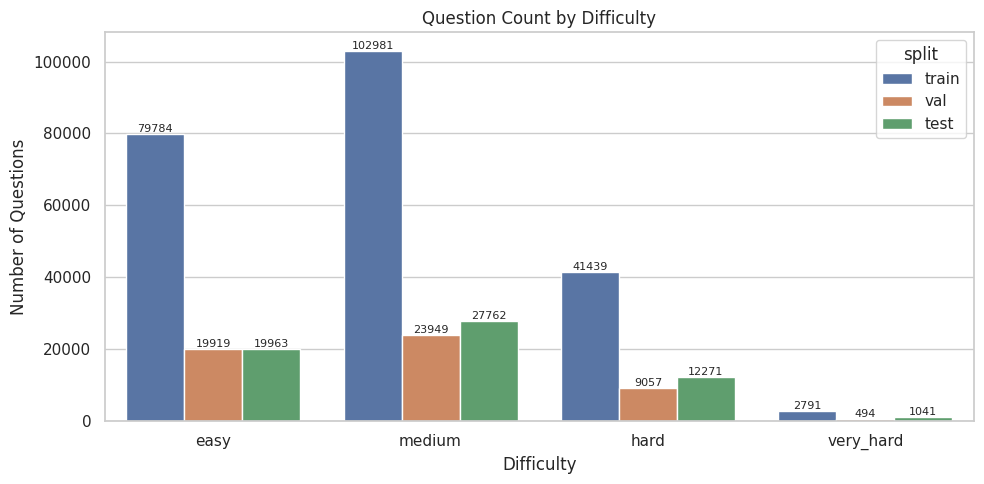

In [7]:
DIFFICULTY_ORDER = ["easy", "medium", "hard", "very_hard"]

diff_rows = []
for split_name, r in results.items():
    for diff, count in r["difficulty"].items():
        diff_rows.append({"split": split_name, "difficulty": diff, "count": count})

df_diff = pd.DataFrame(diff_rows)
if not df_diff.empty:
    present = [d for d in DIFFICULTY_ORDER if d in df_diff["difficulty"].values]
    extra = sorted(set(df_diff["difficulty"]) - set(DIFFICULTY_ORDER))
    order = present + extra

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=df_diff, x="difficulty", y="count", hue="split", order=order, ax=ax)
    ax.set_title("Question Count by Difficulty")
    ax.set_xlabel("Difficulty")
    ax.set_ylabel("Number of Questions")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", fontsize=8)
    plt.tight_layout()
    plt.savefig("difficulty_distribution.png", dpi=150)
    plt.show()
else:
    print("No difficulty data to plot.")

## 6. Question type distribution (horizontal bar chart)

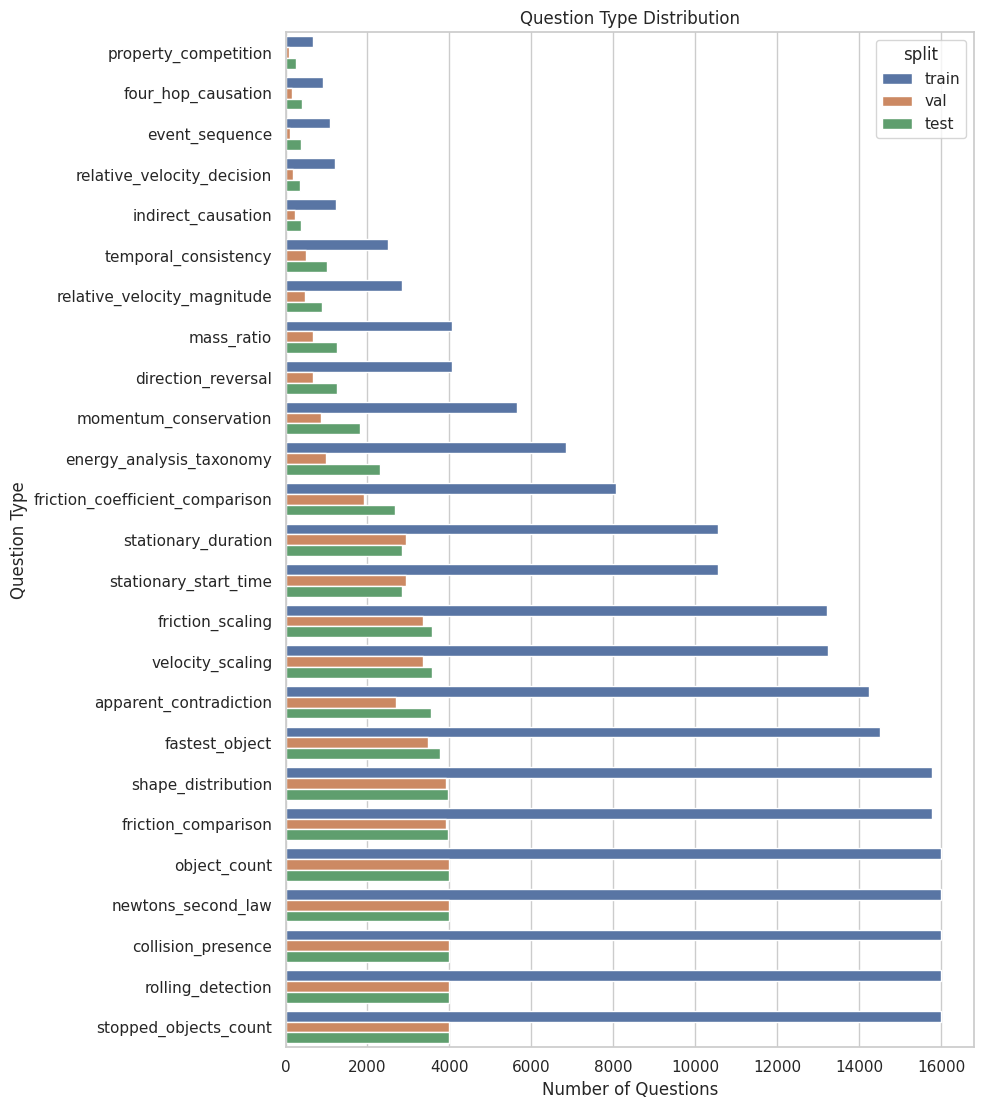

In [8]:
qt_rows = []
for split_name, r in results.items():
    for qt, count in r["question_type"].items():
        qt_rows.append({"split": split_name, "question_type": qt, "count": count})

df_qt = pd.DataFrame(qt_rows)
if not df_qt.empty:
    totals = df_qt.groupby("question_type")["count"].sum().sort_values(ascending=True)
    order = totals.index.tolist()

    fig, ax = plt.subplots(figsize=(10, max(4, len(order) * 0.45)))
    sns.barplot(data=df_qt, y="question_type", x="count", hue="split", order=order, ax=ax)
    ax.set_title("Question Type Distribution")
    ax.set_xlabel("Number of Questions")
    ax.set_ylabel("Question Type")
    plt.tight_layout()
    plt.savefig("question_type_distribution.png", dpi=150)
    plt.show()
else:
    print("No question type data to plot.")

## 7. Answer format distribution

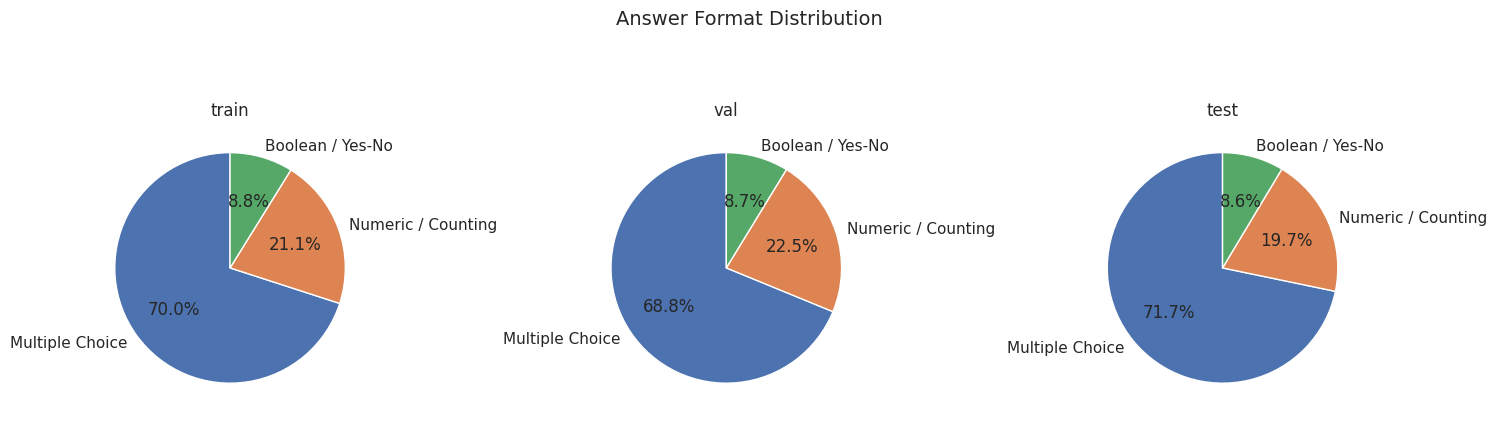

In [9]:
af_rows = []
for split_name, r in results.items():
    for af, count in r["answer_format"].items():
        af_rows.append({"split": split_name, "answer_format": af, "count": count})

df_af = pd.DataFrame(af_rows)
if not df_af.empty:
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
    if len(results) == 1:
        axes = [axes]
    for ax, (split_name, r) in zip(axes, results.items()):
        counts = r["answer_format"]
        if counts:
            labels = list(counts.keys())
            values = list(counts.values())
            ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
            ax.set_title(f"{split_name}")
    plt.suptitle("Answer Format Distribution", fontsize=14)
    plt.tight_layout()
    plt.savefig("answer_format_distribution.png", dpi=150)
    plt.show()
else:
    print("No answer format data to plot.")

## 8. Difficulty histogram per split (individual charts)

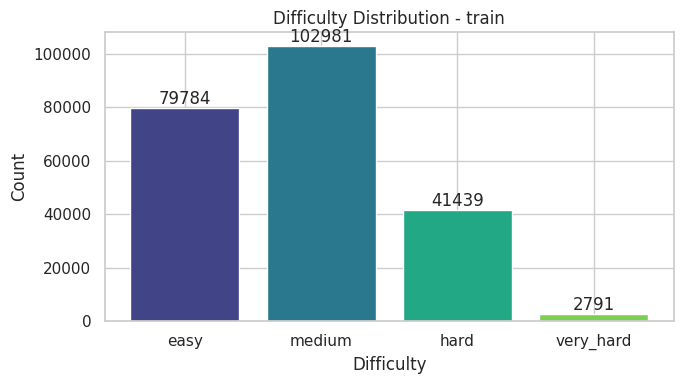

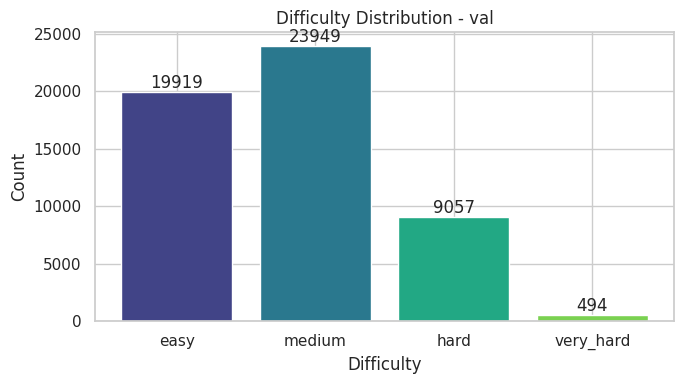

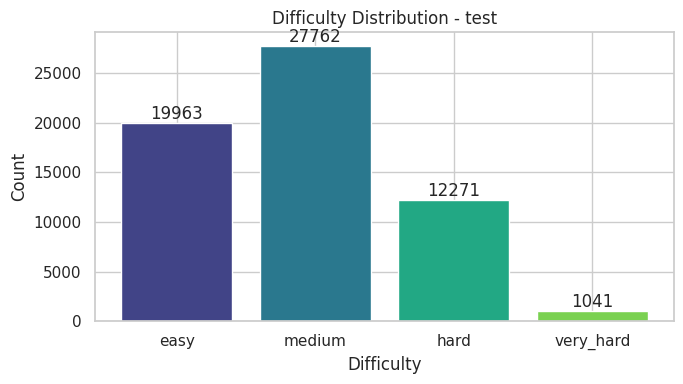

In [10]:
for split_name, r in results.items():
    counts = r["difficulty"]
    if not counts:
        continue
    ordered = [(d, counts.get(d, 0)) for d in DIFFICULTY_ORDER if d in counts]
    extras = [(d, c) for d, c in counts.items() if d not in DIFFICULTY_ORDER]
    ordered += extras
    labels, values = zip(*ordered) if ordered else ([], [])

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, values, color=sns.color_palette("viridis", len(labels)))
    ax.bar_label(bars, fmt="%d")
    ax.set_title(f"Difficulty Distribution - {split_name}")
    ax.set_xlabel("Difficulty")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

## 9. Save results

In [11]:
with open("phlop_data_analysis.json", "w") as f:
    json.dump(results, f, indent=2)
print("Wrote phlop_data_analysis.json")

csv_rows = []
for split_name, r in results.items():
    for d, c in r["difficulty"].items():
        csv_rows.append({"split": split_name, "difficulty": d, "count": c})
df_csv = pd.DataFrame(csv_rows)
df_csv.to_csv("question_counts_by_difficulty.csv", index=False)
print("Wrote question_counts_by_difficulty.csv")
display(df_csv)

Wrote phlop_data_analysis.json
Wrote question_counts_by_difficulty.csv


,split,difficulty,count
0,train,medium,102981
1,train,easy,79784
2,train,hard,41439
3,train,very_hard,2791
4,val,medium,23949
5,val,easy,19919
6,val,hard,9057
7,val,very_hard,494
8,test,medium,27762
9,test,easy,19963


In [12]:
df_csv.to_csv("/content/drive/MyDrive/Uni/MS Project/question_counts_by_difficulty.csv", index=False)